#  Introduction to the Transformer:

The Transformer is the first transduction model relying entirely on self-attention to compute representations of its input and output without using sequence-aligned RNNs or convolution. The idea behind Transformer is to handle the dependencies between input and output with attention and recurrence completely.


**Transformer’s Model Architecture:**

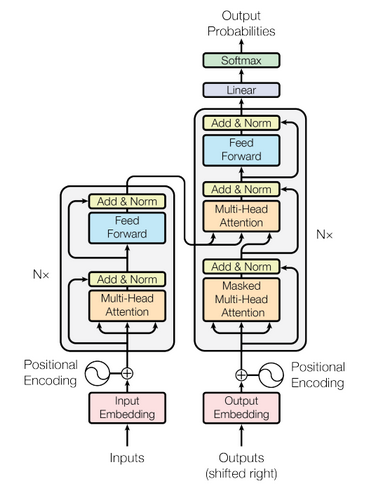

 Let’s first focus on the Encoder and Decoder parts only.Now focus on the below image. The Encoder block has 1 layer of a Multi-Head Attention followed by another layer of Feed Forward Neural Network. The decoder, on the other hand, has an extra Masked Multi-Head Attention.

 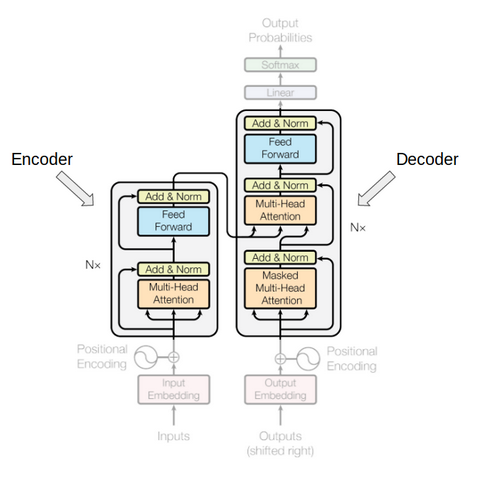

 Encoder: The encoder is composed of a stack of N = 6 identical layers. Each layer has two sub-layers. The first is a multi-head self-attention mechanism, and the second is a simple, positionwise fully connected feed-forward network. We employ a residual connection around each ofthe two sub-layers, followed by layer normalization. That is, the output of each sub-layer is LayerNorm(x + Sublayer(x)),where Sublayer(x) is the function implemented by the sub-layeritself. To facilitate these residual connections, all sub-layers in the model, as well as the embeddinglayers, produce outputs of dimension dmodel = 512.

 Decoder: The decoder is also composed of a stack of N = 6 identical layers. In addition to the two sub-layers in each encoder layer, the decoder inserts a third sub-layer, which performs multi-head attention over the output of the encoder stack. Similar to the encoder, we employ residual connections around each of the sub-layers, followed by layer normalization. We also modify the self-attention sub-layer in the decoder stack to prevent positions from attending to subsequent positions. This masking, combined with fact that the output embeddings are offset by one position, ensures that the predictions for position i can depend only on the known outputs at positions less than i.

 The encoder and decoder blocks are actually multiple identical encoders and decoders stacked on top of each other. Both the encoder stack and the decoder stack have the same number of units.The number of encoder and decoder units is a hyperparameter 

 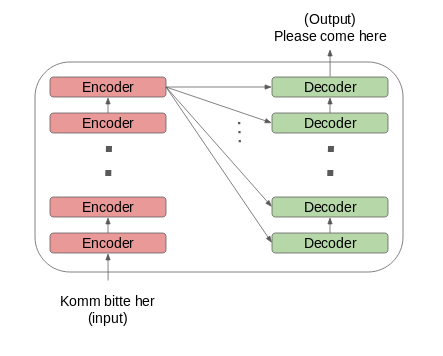

 Let’s see how this setup of the encoder and the decoder stack works:

- The word embeddings of the input sequence are passed to the first encoder
- These are then transformed and propagated to the next encoder
- The output from the last encoder in the encoder-stack is passed to all the decoders in the decoder-stack as shown in the figure below:

An important thing to note here – in addition to the self-attention and feed-forward layers, the decoders also have one more layer of Encoder-Decoder Attention layer. This helps the decoder focus on the appropriate parts of the input sequence.


**Understanding self attention:**

Self-attention, sometimes called intra-attention, is an attention mechanism relating different positions of a single sequence in order to compute a representation of the sequence.

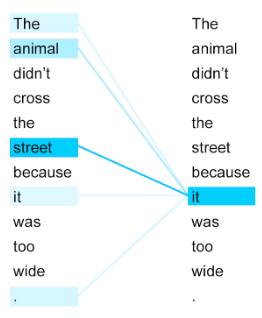


2. Introduction to the Transformer:

The Transformer is the first transduction model relying entirely on self-attention to compute representations of its input and output without using sequence-aligned RNNs or convolution. The idea behind Transformer is to handle the dependencies between input and output with attention and recurrence completely.
2.1 Transformer’s Model Architecture:


Let’s first focus on the Encoder and Decoder parts only.Now focus on the below image. The Encoder block has 1 layer of a Multi-Head Attention followed by another layer of Feed Forward Neural Network. The decoder, on the other hand, has an extra Masked Multi-Head Attention.

Encoder: The encoder is composed of a stack of N = 6 identical layers. Each layer has two sub-layers. The first is a multi-head self-attention mechanism, and the second is a simple, positionwise fully connected feed-forward network. We employ a residual connection around each ofthe two sub-layers, followed by layer normalization. That is, the output of each sub-layer is LayerNorm(x + Sublayer(x)),where Sublayer(x) is the function implemented by the sub-layeritself. To facilitate these residual connections, all sub-layers in the model, as well as the embeddinglayers, produce outputs of dimension dmodel = 512.

Decoder: The decoder is also composed of a stack of N = 6 identical layers. In addition to the two sub-layers in each encoder layer, the decoder inserts a third sub-layer, which performs multi-head attention over the output of the encoder stack. Similar to the encoder, we employ residual connections around each of the sub-layers, followed by layer normalization. We also modify the self-attention sub-layer in the decoder stack to prevent positions from attending to subsequent positions. This masking, combined with fact that the output embeddings are offset by one position, ensures that the predictions for position i can depend only on the known outputs at positions less than i.

The encoder and decoder blocks are actually multiple identical encoders and decoders stacked on top of each other. Both the encoder stack and the decoder stack have the same number of units.The number of encoder and decoder units is a hyperparameter


Let’s see how this setup of the encoder and the decoder stack works:

    The word embeddings of the input sequence are passed to the first encoder
    These are then transformed and propagated to the next encoder
    The output from the last encoder in the encoder-stack is passed to all the decoders in the decoder-stack as shown in the figure below:

An important thing to note here – in addition to the self-attention and feed-forward layers, the decoders also have one more layer of Encoder-Decoder Attention layer. This helps the decoder focus on the appropriate parts of the input sequence.
2.2 Understanding self attention:

Self-attention, sometimes called intra-attention, is an attention mechanism relating different positions of a single sequence in order to compute a representation of the sequence.

Take a look at the above image. Can you figure out what the term “it” in this sentence refers to?

Is it referring to the street or to the animal? It’s a simple question for us but not for an algorithm. When the model is processing the word “it”, self-attention tries to associate “it” with “animal” in the same sentence.

Self-attention allows the model to look at the other words in the input sequence to get a better understanding of a certain word in the sequence.

Self-attention is computed not once but multiple times in the Transformer’s architecture, in parallel and independently. It is therefore referred to as Multi-head Attention. The outputs are concatenated and linearly transformed as shown in the figure below: 

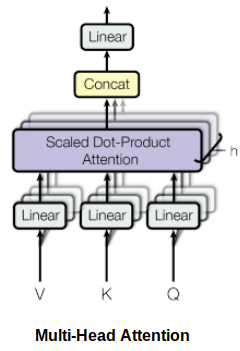

Multi-head attention allows the model to jointly attend to information from different representation subspaces at different positions.

**Limitations of the Transformer:**

Attention can only deal with fixed-length text strings. The text has to be split into a certain number of segments or chunks before being fed into the system as input This chunking of text causes context fragmentation. For example, if a sentence is split from the middle, then a significant amount of context is lost. In other words, the text is split without respecting the sentence or any other semantic boundary 

But,undoutedly transformer inspired BERT and all the following breakthroughs in NLP.


# Understanding BERT (Bidirectional Encoder Representations from Transformers): 

BERT is designed to pretrain deep bidirectional representations from unlabeled text by jointly conditioning on both left and right context in all layers. As a result, the pre-trained BERT model can be finetuned with just one additional output layer to create state-of-the-art models for a wide range of tasks, such as question answering and language inference, without substantial taskspecific architecture modifications.

BERT is a deeply bidirectional model. Bidirectional means that BERT learns information from both the left and the right side of a token’s context during the training phase.

The bidirectionality of a model is important for truly understanding the meaning of a language. Let’s see an example to illustrate this. There are two sentences in this example and both of them involve the word “bank”:

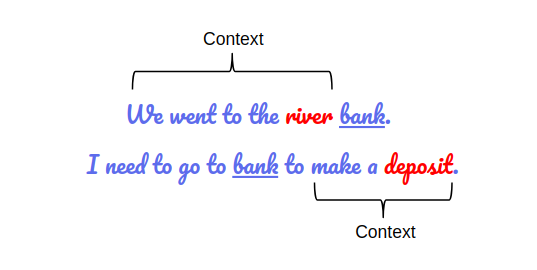

If we try to predict the nature of the word “bank” by only taking either the left or the right context, then we will be making an error in at least one of the two given examples.One way to deal with this is to consider both the left and the right context before making a prediction. That’s exactly what BERT does. 

### How Does BERT Work? 

**BERT’s Architecture:**

The BERT architecture builds on top of Transformer. We currently have two variants available:

- BERT Base: 12 layers (transformer blocks), 12 attention heads, and 110 million parameters
- BERT Large: 24 layers (transformer blocks), 16 attention heads and, 340 million parameters

All of these Transformer layers are Encoder-only blocks.

Now that we know the overall architecture of BERT, let’s see what kind of text processing steps are required before we get to the model building phase.

**Text processing for BERT:**

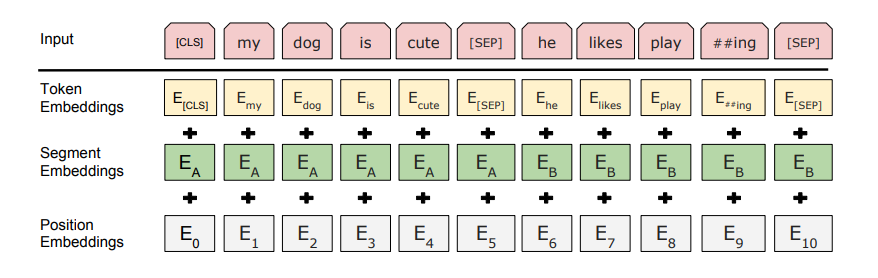

 For bert,every input embedding is a combination of 3 embeddings:

 Position Embeddings: BERT learns and uses positional embeddings to express the position of words in a sentence. These are added to overcome the limitation of Transformer which, unlike an RNN, is not able to capture “sequence” or “order” information

 Segment Embeddings: BERT can also take sentence pairs as inputs for tasks (Question-Answering). That’s why it learns a unique embedding for the first and the second sentences to help the model distinguish between them. In the above example, all the tokens marked as EA belong to sentence A (and similarly for EB)

Token Embeddings: These are the embeddings learned for the specific token from the WordPiece token vocabulary


For a given token, its input representation is constructed by summing the corresponding token, segment, and position embeddings.Such a comprehensive embedding scheme contains a lot of useful information for the model.These combinations of preprocessing steps make BERT so versatile.


When training language models, there is a challenge of defining a prediction goal. Many models predict the next word in a sequence, a directional approach which inherently limits context learning. To overcome this challenge, BERT uses two training strategies:

**1. Masked LM (MLM):**

Before feeding word sequences into BERT, 15% of the words in each sequence are replaced with a [MASK] token. The model then attempts to predict the original value of the masked words, based on the context provided by the other, non-masked, words in the sequence. In technical terms, the prediction of the output words requires:

1. Adding a classification layer on top of the encoder output.
2. Multiplying the output vectors by the embedding matrix, transforming them into the vocabulary dimension.
3. Calculating the probability of each word in the vocabulary with softmax.

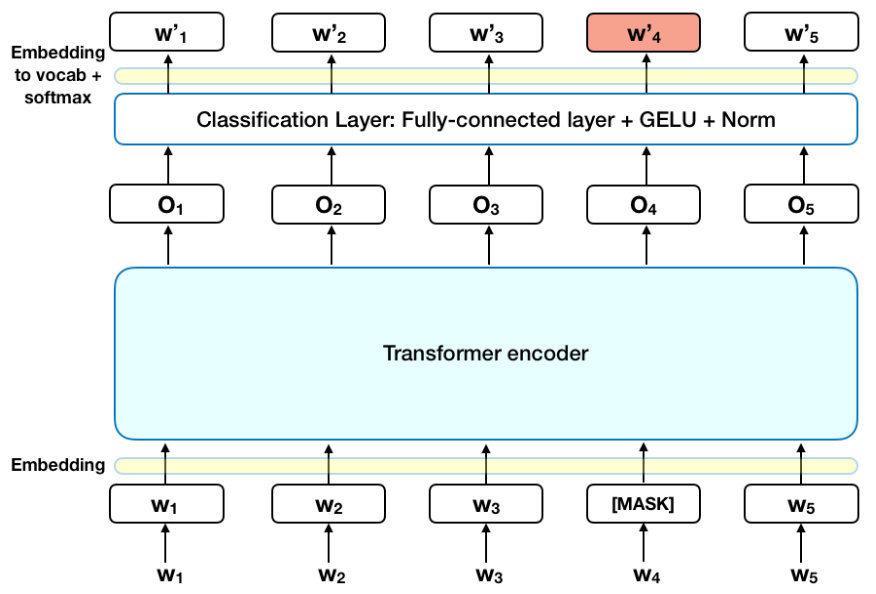

 The BERT loss function takes into consideration only the prediction of the masked values and ignores the prediction of the non-masked words. As a consequence, the model converges slower than directional models, a characteristic which is offset by its increased context awareness.

 **2. Next Sentence Prediction (NSP):**

 In the BERT training process, the model receives pairs of sentences as input and learns to predict if the second sentence in the pair is the subsequent sentence in the original document. During training, 50% of the inputs are a pair in which the second sentence is the subsequent sentence in the original document, while in the other 50% a random sentence from the corpus is chosen as the second sentence. The assumption is that the random sentence will be disconnected from the first sentence.

  To help the model distinguish between the two sentences in training, the input is processed in the following way before entering the model:

1. A [CLS] token is inserted at the beginning of the first sentence and a [SEP] token is inserted at the end of each sentence.
2. A sentence embedding indicating Sentence A or Sentence B is added to each token. Sentence embeddings are similar in concept to token embeddings with a vocabulary of 2.
3. A positional embedding is added to each token to indicate its position in the sequence. The concept and implementation of positional embedding are presented in the Transformer paper. 

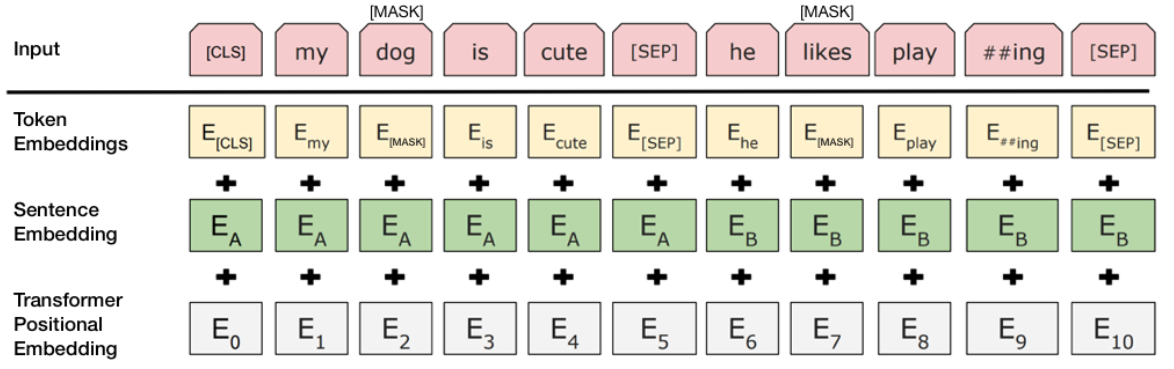

To predict if the second sentence is indeed connected to the first, the following steps are performed:

1. The entire input sequence goes through the Transformer model.
2. The output of the [CLS] token is transformed into a 2×1 shaped vector, using a simple classification layer (learned matrices of weights and biases).
3. Calculating the probability of IsNextSequence with softmax.


When training the BERT model, Masked LM and Next Sentence Prediction are trained together, with the goal of minimizing the combined loss function of the two strategies.

# How to use BERT (Fine-tuning):


 BERT can be used for a wide variety of language tasks, while only adding a small layer to the core model:

1. Classification tasks such as sentiment analysis are done similarly to Next Sentence classification, by adding a classification layer on top of the Transformer output for the [CLS] token.
2. In Question Answering tasks (e.g. SQuAD v1.1), the software receives a question regarding a text sequence and is required to mark the answer in the sequence. Using BERT, a Q&A model can be trained by learning two extra vectors that mark the beginning and the end of the answer.
3. In Named Entity Recognition (NER), the software receives a text sequence and is required to mark the various types of entities (Person, Organization, Date, etc) that appear in the text. Using BERT, a NER model can be trained by feeding the output vector of each token into a classification layer that predicts the NER label.

# Takeaways:

1. Model size matters, even at huge scale. BERT_large, with 345 million parameters, is the largest model of its kind. It is demonstrably superior on small-scale tasks to BERT_base, which uses the same architecture with “only” 110 million parameters.
2. With enough training data, more training steps == higher accuracy. For instance, on the MNLI task, the BERT_base accuracy improves by 1.0% when trained on 1M steps (128,000 words batch size) compared to 500K steps with the same batch size.
3. BERT’s bidirectional approach (MLM) converges slower than left-to-right approaches (because only 15% of words are predicted in each batch) but bidirectional training still outperforms left-to-right training after a small number of pre-training steps.

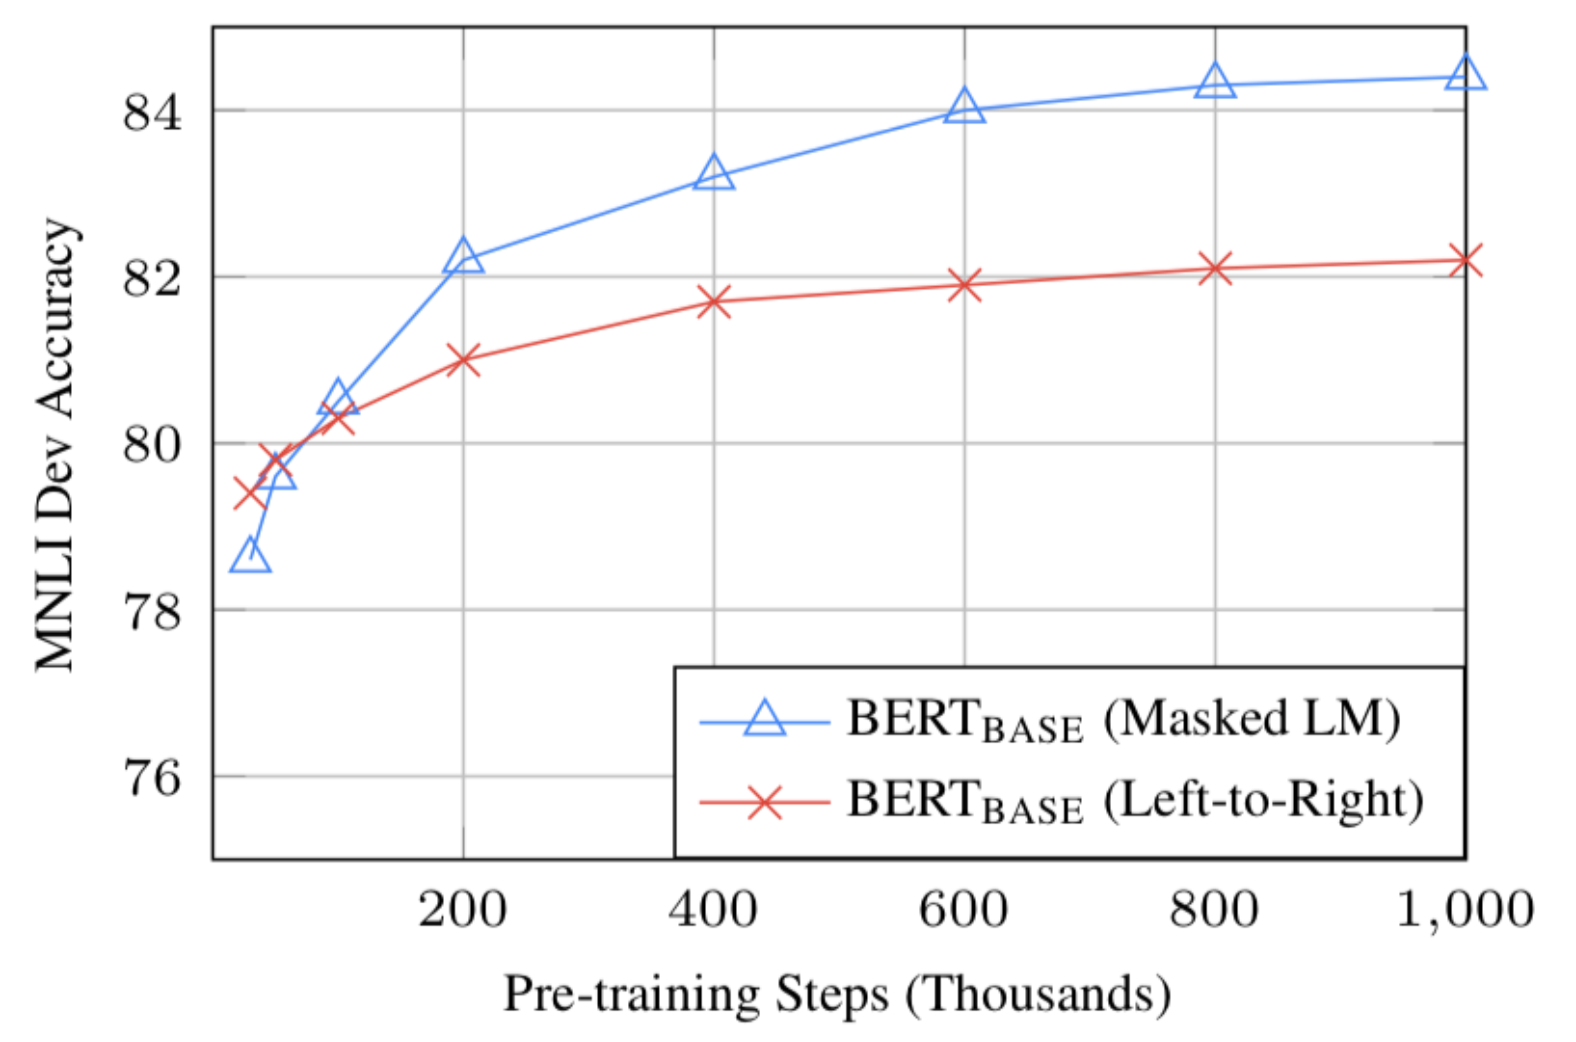



In [1]:
import tensorflow_hub as hub


ModuleNotFoundError: No module named 'tensorflow_hub'

In [2]:
!pip install tensorflow_hub

  Using cached protobuf-7.34.1-cp310-abi3-manylinux2014_x86_64.whl.metadata (595 bytes)
  Using cached numpy-2.2.6-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (62 kB)
  Using cached h5py-3.14.0-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (2.7 kB)
  Using cached ml_dtypes-0.5.4-cp310-cp310-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (8.9 kB)
  Using cached rich-14.3.3-py3-none-any.whl.metadata (18 kB)
  Using cached namex-0.1.0-py3-none-any.whl.metadata (322 bytes)
  Using cached optree-0.19.0-cp310-cp310-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (34 kB)
  Using cached markdown_it_py-4.0.0-py3-none-any.whl.metadata (7.3 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 946.1 kB/s  0:00:02 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/572.2 MB 1.1 MB/s eta 0:08:420m
ERROR: Operation cancelled by user
^C
